In [4]:
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog
import matplotlib.pyplot as plt

In [5]:
def load_images_folder_histogram(directory):
# 54.285714285714285 3
    data = []
    labels = []
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

    # Getting path of image files one-by-one from a sub-folder 'subdir_path'
        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                #Checking whether obtained path is a filepath
                if os.path.isfile(filepath):

                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE

                    image = cv2.resize(image, (64, 64))  # Resize to 64x64 pixels

                    arr = image.flatten() #flattening the image of size 64x64 to make one-dimentional array
                    arr1 = np.histogram(arr,10) #Computation of histogram of the array with 256 bins
                    # arr1 = [np.average(arr), np.max(arr), np.median(arr)]  #Other features

                    # data.append(image.flatten())  # Flatten the image

                    #Assigning suitable tables to different classes
                    data.append(arr1[0])
                    if subdir == 'dogs':
                        labels.append(0)  # May use the folder name as the label
                    else:
                        labels.append(1)

    return np.array(data), np.array(labels)  #Convering results to Numpy arrays

In [13]:
def load_images_folder_mmm(directory):
# 60.0 17
    data = []
    labels = []
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

    # Getting path of image files one-by-one from a sub-folder 'subdir_path'
        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                #Checking whether obtained path is a filepath
                if os.path.isfile(filepath):

                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE

                    image = cv2.resize(image, (64, 64))  # Resize to 64x64 pixels

                    arr = image.flatten() #flattening the image of size 64x64 to make one-dimentional array
                    # arr1 = np.histogram(arr,10) #Computation of histogram of the array with 256 bins
                    arr1 = [np.average(arr), np.max(arr), np.median(arr)]  #Other features

                    # data.append(image.flatten())  # Flatten the image

                    #Assigning suitable tables to different classes
                    data.append(arr1)
                    if subdir == 'dogs':
                        labels.append(0)  # May use the folder name as the label
                    else:
                        labels.append(1)

    return np.array(data), np.array(labels)  #Convering results to Numpy arrays

In [14]:
def load_images_folder_gabor(directory):
    # 67.14285714285714 70
    data = []
    labels = []

    # Gabor filter parameters
    ksize = 5  # Kernel size
    sigma = 1.0
    lambd = 10.0
    gamma = 0.5
    thetas = [0, 45, 90, 135]  # Orientations in degrees

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                if os.path.isfile(filepath):
                    # Load and preprocess image
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    image = cv2.resize(image, (64, 64))  # Resize to 64x64

                    gabor_features = []
                    for theta in thetas:
                        theta_rad = np.deg2rad(theta)
                        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta_rad, lambd, gamma, 0, ktype=cv2.CV_32F)
                        filtered_img = cv2.filter2D(image, cv2.CV_8UC3, kernel)  # Apply Gabor filter

                        gabor_features.append(np.mean(filtered_img))  # Mean response
                        gabor_features.append(np.var(filtered_img))   # Variance response

                    data.append(gabor_features)  # Store extracted features

                    # Assign class labels
                    labels.append(0 if subdir == 'dogs' else 1)

    return np.array(data), np.array(labels)  # Convert to NumPy arrays

In [15]:
def load_images_folder_hog(directory):
# 67.14285714285714 37
    data = []
    labels = []

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        if os.path.isdir(subdir_path):
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)

                if os.path.isfile(filepath):
                    # Load and preprocess image
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    image = cv2.resize(image, (64, 64))  # Resize to 64x64

                    # Extract HOG features
                    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)

                    data.append(hog_features)  # Store extracted HOG features

                    # Assign class labels
                    labels.append(0 if subdir == 'dogs' else 1)

    return np.array(data), np.array(labels)  # Convert to NumPy arrays

In [24]:
# Path to the dataset
dataset_directory1 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/train"
dataset_directory2 = r"C:/D folder/Programming/programs/my codes/ML codes/knn classifier/Dog-Cat Dataset/test"

# Load images and labels
images_train, labels_train = load_images_folder_hog(dataset_directory1)
images_test, labels_test = load_images_folder_hog(dataset_directory2)

In [25]:
images_test.shape

(140, 1764)

In [26]:
# Initialize and train the KNN classifier
acc=[]
for k in range(100):
    knn = KNeighborsClassifier(n_neighbors=k+1)  # Use 3 neighbors for KNN
    knn.fit(images_train, labels_train)

    # Predict on the test set
    y_pred = knn.predict(images_test)

    # Calculate accuracy
    accuracy = accuracy_score(labels_test, y_pred)
    acc.append(100*accuracy)
    #print(f"Classification Accuracy: {accuracy * 100:.2f}%")
print(np.max(acc), np.argmax(acc)+1)

67.14285714285714 37


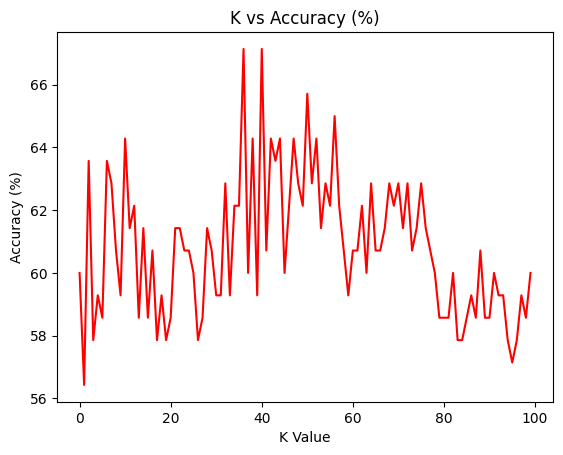

In [27]:
plt.plot(acc, 'red')
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("K vs Accuracy (%)")
plt.show()